In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Get the current working directory of the notebook
current_notebook_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_notebook_dir, os.pardir))

# Add the parent directory to the Python path
sys.path.append(parent_dir)

In [3]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from torchvision import models
import matplotlib.pyplot as plt

from data.datasets import DeepFakeDataset
from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights
import random
from sklearn.model_selection import train_test_split
from PIL import Image

In [4]:
SEED = 8
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
if torch.mps.is_available():
    torch.mps.manual_seed(SEED)

In [5]:
image_metadata_path = "../Deepfake-Eval-2024/image-metadata-publish.csv"
image_dir_path = '../Deepfake-Eval-2024/image-data'

In [6]:
image_metadata_df = pd.read_csv(image_metadata_path)

In [7]:
image_metadata_df[image_metadata_df['Filename']=='#NAME?']

,Filename,Date,Ground Truth,Public Comments,Finetuning Set


In [8]:
image_metadata_df = image_metadata_df[image_metadata_df['Filename']!='#NAME?'].reset_index(drop=True)
image_metadata_df.to_csv(image_metadata_path, index = False)

In [9]:
image_metadata_df.groupby('Ground Truth').agg({
    'Filename': 'count'
})

,Filename
Ground Truth,
Fake,1192
Real,760


In [10]:
image_metadata_df.groupby('Finetuning Set').agg({
    'Filename': 'count'
})

,Filename
Finetuning Set,
Test,786
Train,1166


In [11]:
existing_image_paths = []
missing_files_pre_check = []
for p in image_metadata_df['Filename']:
    if os.path.exists(os.path.join(image_dir_path, p)):
        existing_image_paths.append(p)
    else:
        missing_files_pre_check.append(p)

In [12]:
if missing_files_pre_check:
    print(f"Found {len(missing_files_pre_check)} missing files")
    for mf in missing_files_pre_check:
        print(mf)
else:
    print("All image files exist")

All image files exist


In [13]:
def has_image_issue(image_path):
    try:
        with Image.open(image_path) as img:
            img.load()  # This forces the loading of all image data
        return False  # Image loaded successfully, not truncated
    except Exception:
        # Catch other potential issues with opening/loading
        return True

In [14]:
image_issues = []
for file in image_metadata_df['Filename']:
    if has_image_issue(os.path.join(image_dir_path, file)):
        image_issues.append(file)

image_issues

['c1DVk98VHjpJOPZFOPS9NgCBrRY.jpg', 't1ChhPlw2FBnI3V4AFk9vhYn1qg.jpeg']

In [15]:
def is_image_truncated(image_path):
    try:
        with Image.open(image_path) as img:
            img.load()  # This forces the loading of all image data
        return False  # Image loaded successfully, not truncated
    except OSError as e:
        if "image file is truncated" in str(e):
            return True  # Image is truncated
        else:
            # Other OSError, handle as needed (e.g., file not found, bad header)
            return False
    except Exception:
        # Catch other potential issues with opening/loading
        return False

In [16]:
truncated_images = []
for file in image_metadata_df['Filename']:
    if is_image_truncated(os.path.join(image_dir_path, file)):
        truncated_images.append(file)

truncated_images

['c1DVk98VHjpJOPZFOPS9NgCBrRY.jpg']

In [17]:
image_metadata_df[image_metadata_df['Filename'] == 'c1DVk98VHjpJOPZFOPS9NgCBrRY.jpg']

,Filename,Date,Ground Truth,Public Comments,Finetuning Set
401,c1DVk98VHjpJOPZFOPS9NgCBrRY.jpg,########,Fake,original:,Train


In [18]:
image_metadata_df[image_metadata_df['Filename'] == 't1ChhPlw2FBnI3V4AFk9vhYn1qg.jpeg']

,Filename,Date,Ground Truth,Public Comments,Finetuning Set
1502,t1ChhPlw2FBnI3V4AFk9vhYn1qg.jpeg,9/2/2024,Real,https://www.theguardian.com/us-news/article/20...,Train


In [19]:
drop_condition = (image_metadata_df['Filename'] == 'c1DVk98VHjpJOPZFOPS9NgCBrRY.jpg') | (image_metadata_df['Filename'] == 't1ChhPlw2FBnI3V4AFk9vhYn1qg.jpeg')
indices_to_drop = image_metadata_df[drop_condition].index
image_metadata_df.drop(indices_to_drop, inplace=True)

In [20]:
# Train test split
train_df, val_test_df = train_test_split(
    image_metadata_df,
    test_size=0.3, # 30% for validation and test
    stratify=image_metadata_df['Ground Truth'], # Stratify by the 'Ground Truth' column
    random_state=7
)

val_df, test_df = train_test_split(
    val_test_df,
    test_size=0.5, # 50% of the val_test_df (15% of original)
    stratify=val_test_df['Ground Truth'],
    random_state=7
)

In [21]:
train_image_metadata_path = "../image-metadata-train.csv"
val_image_metadata_path = "../image-metadata-val.csv"
test_image_metadata_path = "../image-metadata-test.csv"
train_df.to_csv(train_image_metadata_path, index = False)
val_df.to_csv(val_image_metadata_path, index = False)
test_df.to_csv(test_image_metadata_path, index = False)

In [22]:
def denormalize_image(tensor, mean, std):
    """
    Denormalizes a tensor (C, H, W) using the provided mean and standard deviation.
    """
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(-1, 1, 1)

    # Perform the denormalization operation
    denormalized_tensor = tensor * std_tensor + mean_tensor

    denormalized_tensor = torch.clamp(denormalized_tensor, 0.0, 1.0) # Assuming original values were in [0, 1]

    return denormalized_tensor

In [23]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

In [24]:
training_data_resnet = DeepFakeDataset(train_image_metadata_path, image_dir_path, model_type='ResNet', is_train=True)

In [25]:
training_dataloader = DataLoader(training_data_resnet, batch_size = 1, shuffle=True, num_workers=0)

In [26]:
corrupted_or_missing_samples = []
for i, (data, label) in enumerate(training_dataloader):
    try:
        pass
    except Exception as e:
        corrupted_or_missing_samples.append(f"Error loading sample at index {i}: {e}")

In [27]:
corrupted_or_missing_samples

[]

In [28]:
val_data_resnet = DeepFakeDataset(val_image_metadata_path, image_dir_path, model_type='ResNet', is_train=True)
val_dataloader = DataLoader(val_data_resnet, batch_size = 1, shuffle=True, num_workers=0)

In [29]:
corrupted_or_missing_samples = []
for i, (data, label) in enumerate(val_dataloader):
    try:
        pass
    except Exception as e:
        corrupted_or_missing_samples.append(f"Error loading sample at index {i}: {e}")
corrupted_or_missing_samples

[]

In [30]:
test_data_resnet = DeepFakeDataset(test_image_metadata_path, image_dir_path, model_type='ResNet', is_train=True)
test_dataloader = DataLoader(test_data_resnet, batch_size = 1, shuffle=True, num_workers=0)

In [31]:
corrupted_or_missing_samples = []
for i, (data, label) in enumerate(test_dataloader):
    try:
        pass
    except Exception as e:
        corrupted_or_missing_samples.append(f"Error loading sample at index {i}: {e}")
corrupted_or_missing_samples

[]

In [32]:
training_dataloader = DataLoader(training_data_resnet, batch_size = 32, shuffle=True, num_workers=0)

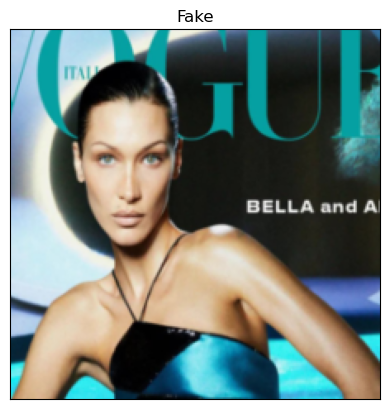

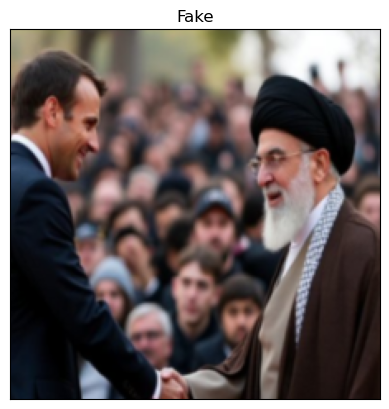

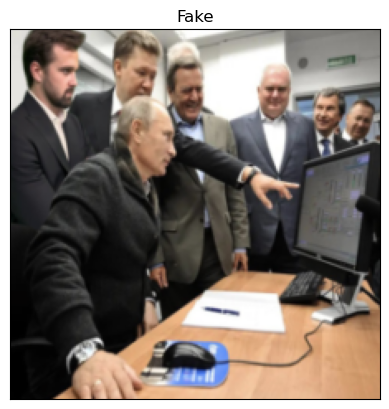

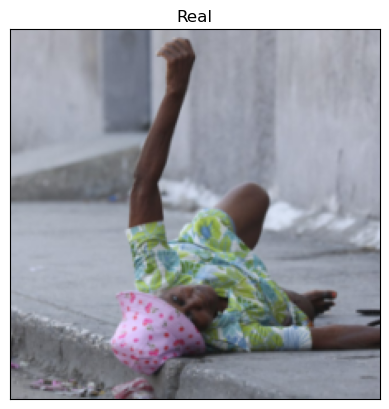

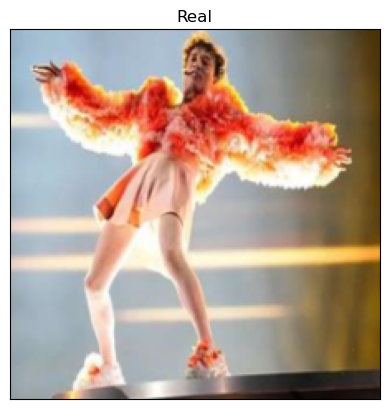

In [33]:
count = 0
features, label = next(iter(training_dataloader))
for i in range(5):
    img = features[i]
    denormalized_tensor = denormalize_image(img, mean, std)
    plt.imshow(np.transpose(denormalized_tensor, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()

In [34]:
val_data_resnet = DeepFakeDataset(val_image_metadata_path, image_dir_path, model_type='ResNet', is_train=False)
val_dataloader = DataLoader(val_data_resnet, batch_size = 32, shuffle=True)

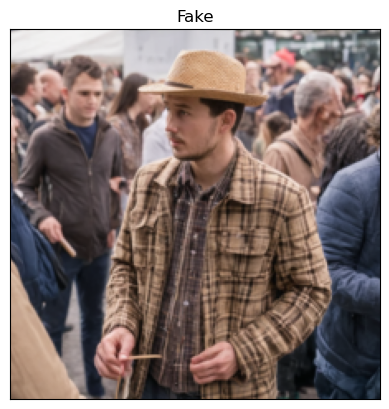

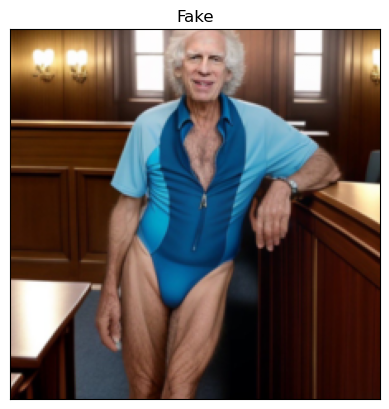

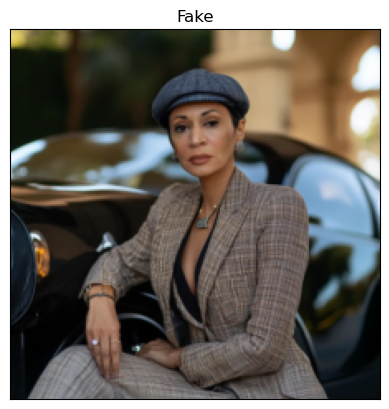

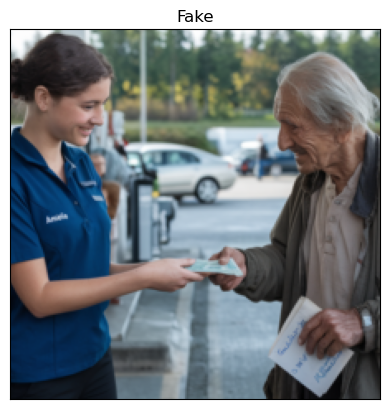

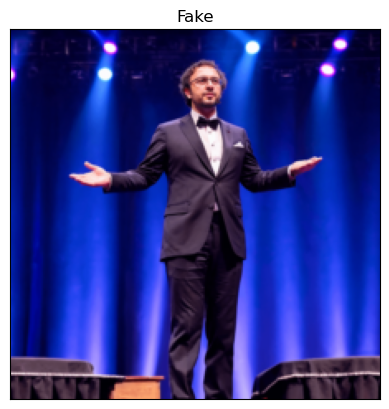

In [35]:
count = 0
features, label = next(iter(val_dataloader))
for i in range(5):
    img = features[i]
    denormalized_tensor = denormalize_image(img, mean, std)
    plt.imshow(np.transpose(denormalized_tensor, (1,2,0))) # convert pytorch tensor (3 channels, H, W) to numpy array (H, W, 3 channels)
    plt.title("Fake" if label[i] else "Real")
    plt.xticks([])
    plt.yticks([])
    plt.show()